# Quantum Finance — Sistema de Recomendação
## Open Finance · Abordagem Híbrida · Filtro Colaborativo + Knowledge-Based

---

A **Quantum Finance** é uma Fintech especializada em **crédito pessoal e consignado**.  
Com a adesão ao **Open Finance**, passamos a ter acesso ao perfil financeiro consolidado
dos clientes em múltiplas instituições (mediante consentimento).

**Objetivo deste notebook:**  
Demonstrar que a técnica de **Filtragem Colaborativa Baseada em Usuário** combinada com
**Recomendação Baseada em Conhecimento** (Knowledge-Based com Popularidade) é factível
ao dataset do Open Finance e pode gerar recomendações personalizadas de produtos financeiros.

**Abordagem:** Híbrida — User-Based CF (Python) + Knowledge-Based (SQLite) + Market Intelligence (Open Finance APIs)  
**Propriedades do SR:** Similaridade · Personalização · Popularidade · Ranqueamento  
**Dataset:** Clientes e produtos financeiros — Open Finance (PoC)

| Camada | Técnica | Responsabilidade |
|---|---|---|
| 1 | User-Based CF | Distância Euclidiana → Similaridade → Recomendação ponderada |
| 2 | Knowledge-Based | SQLite + Popularidade (quantidadeLikes) |
| 3 | Market Intelligence | APIs Open Finance → Taxas reais → Proposta QF (−5%) |

## Dataset Open Finance

Os dados representam clientes com seus produtos financeiros e um **score de uso/engajamento (1–7)**.  
Scores mais altos indicam maior engajamento com o produto.  
A **ausência** de um produto no perfil indica que o cliente não o possui — tornando-o candidato à recomendação.

| Score | Interpretação |
|---|---|
| 1–2 | Uso esporádico / baixo engajamento |
| 3–4 | Uso moderado |
| 5–6 | Uso intenso — produto principal |
| 7 | Produto âncora — máxima fidelidade |
| ausente | Cliente não possui → candidato à recomendação |

In [1]:
# Dataset Open Finance — Quantum Finance
# Cada valor representa o score de uso/interesse do cliente com o produto (escala 1-7)

clientes = {
    'Ana': {
        'Cartão de Crédito': 1,
        'Conta Corrente': 2,
        'Poupança': 3,
        'Renda Fixa': 4,
        'Crédito Pessoal': 5
    },
    'Marcos': {
        'Cartão de Crédito': 2,
        'Conta Corrente': 3,
        'Poupança': 4,
        'Renda Fixa': 5,
        'Renda Variável': 0.6
    },
    'Pedro': {
        'Cartão de Crédito': 3,
        'Conta Corrente': 4,
        'Poupança': 5,
        'Crédito Pessoal': 7
    },
    'Claudia': {
        'Cartão de Crédito': 4,
        'Conta Corrente': 5,
        'Poupança': 6
    }
}

print("Clientes no dataset:", list(clientes.keys()))
print("Produtos únicos:", sorted({p for c in clientes.values() for p in c}))
print(f"\nTotal: {len(clientes)} clientes | {len({p for c in clientes.values() for p in c})} produtos distintos")

Clientes no dataset: ['Ana', 'Marcos', 'Pedro', 'Claudia']
Produtos únicos: ['Cartão de Crédito', 'Conta Corrente', 'Crédito Pessoal', 'Poupança', 'Renda Fixa', 'Renda Variável']

Total: 4 clientes | 6 produtos distintos


## Distância Euclidiana

Medimos a "distância" entre dois clientes com base nos produtos que **ambos possuem em comum**.  
Quanto **menor** a distância, mais parecidos são os clientes em seus comportamentos.

Códigos de retorno especiais:  
`-1` = usuario1 inexistente · `-2` = usuario2 inexistente · `-3` = sem produtos em comum

In [2]:
from math import sqrt

def euclidiana(usuario1, usuario2):
    si = {}
    if usuario1 not in clientes: return -1
    if usuario2 not in clientes: return -2
    for item in clientes[usuario1]:
        if item in clientes[usuario2]:
            si[item] = 1
    if len(si) == 0: return -3
    soma = sum([
        pow(clientes[usuario1][item] - clientes[usuario2][item], 2)
        for item in clientes[usuario1] if item in clientes[usuario2]
    ])
    return sqrt(soma)

# Teste — distâncias a partir de Ana
print("Distâncias a partir de Ana:")
for outro in [c for c in clientes if c != 'Ana']:
    print(f"  Ana → {outro:<10}: {euclidiana('Ana', outro):.4f}")

print("\nDistâncias entre todos os pares:")
nomes = list(clientes.keys())
for i, u1 in enumerate(nomes):
    for u2 in nomes[i+1:]:
        print(f"  {u1} ↔ {u2}: {euclidiana(u1, u2):.4f}")

Distâncias a partir de Ana:
  Ana → Marcos    : 2.0000
  Ana → Pedro     : 4.0000
  Ana → Claudia   : 5.1962

Distâncias entre todos os pares:
  Ana ↔ Marcos: 2.0000
  Ana ↔ Pedro: 4.0000
  Ana ↔ Claudia: 5.1962
  Marcos ↔ Pedro: 1.7321
  Marcos ↔ Claudia: 3.4641
  Pedro ↔ Claudia: 1.7321


## Similaridade entre Clientes

Convertemos a distância em um **score de similaridade entre 0 e 1**.  
Score 1 = clientes idênticos. Score próximo de 0 = clientes muito diferentes.

In [3]:
def similaridade(usuario1, usuario2):
    de = euclidiana(usuario1, usuario2)
    if de < 0:
        return 0
    return 1 / (1 + de)

# Teste — similaridades a partir de Ana
print("Similaridades a partir de Ana:")
for outro in [c for c in clientes if c != 'Ana']:
    print(f"  Ana ↔ {outro:<10}: {similaridade('Ana', outro):.4f}")

print("\nSimilaridades entre todos os pares:")
for i, u1 in enumerate(nomes):
    for u2 in nomes[i+1:]:
        print(f"  {u1} ↔ {u2}: {similaridade(u1, u2):.4f}")

Similaridades a partir de Ana:
  Ana ↔ Marcos    : 0.3333
  Ana ↔ Pedro     : 0.2000
  Ana ↔ Claudia   : 0.1614

Similaridades entre todos os pares:
  Ana ↔ Marcos: 0.3333
  Ana ↔ Pedro: 0.2000
  Ana ↔ Claudia: 0.1614
  Marcos ↔ Pedro: 0.3660
  Marcos ↔ Claudia: 0.2240
  Pedro ↔ Claudia: 0.3660


## Heatmap de Similaridade entre Todos os Clientes

Visualização da **matriz de similaridade** — permite identificar grupos de clientes com perfis afins.  
A diagonal principal = 1.0 (cada cliente é idêntico a si mesmo).

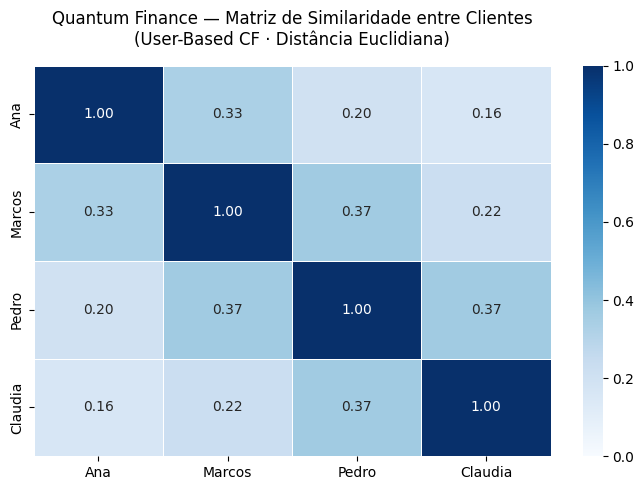


Par mais similar  : ('Marcos', 'Pedro', 0.366)
Par menos similar : ('Ana', 'Claudia', 0.1614)


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (7, 5)

# Construir matriz de similaridade
nomes = list(clientes.keys())
matriz = pd.DataFrame(index=nomes, columns=nomes, dtype=float)

for u1 in nomes:
    for u2 in nomes:
        matriz.loc[u1, u2] = 1.0 if u1 == u2 else round(similaridade(u1, u2), 4)

# Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    matriz.astype(float),
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    vmin=0,
    vmax=1
)
plt.title("Quantum Finance — Matriz de Similaridade entre Clientes\n(User-Based CF · Distância Euclidiana)", pad=15)
plt.tight_layout()
plt.show()

print("\nPar mais similar  :", max(
    [(u1, u2, round(similaridade(u1, u2), 4)) for i, u1 in enumerate(nomes) for u2 in nomes[i+1:]],
    key=lambda x: x[2]
))
print("Par menos similar :", min(
    [(u1, u2, round(similaridade(u1, u2), 4)) for i, u1 in enumerate(nomes) for u2 in nomes[i+1:]],
    key=lambda x: x[2]
))

## Ranking de Usuários Similares

Para cada cliente, listamos os demais ordenados por **similaridade decrescente**.  
Esses são os "vizinhos" que alimentam o algoritmo de recomendação.

In [5]:
def getSimilares(usuario):
    lista = [
        (round(similaridade(usuario, outro), 4), outro)
        for outro in clientes if outro != usuario
    ]
    lista.sort(reverse=True)
    return lista

# Exibir vizinhos para todos os clientes
for cliente in clientes:
    similares = getSimilares(cliente)
    print(f"\n{'='*42}")
    print(f"  Vizinhos de {cliente}:")
    for score, nome in similares:
        bar = '█' * int(score * 20)
        print(f"    {nome:<10} similaridade: {score:.4f}  {bar}")


  Vizinhos de Ana:
    Marcos     similaridade: 0.3333  ██████
    Pedro      similaridade: 0.2000  ████
    Claudia    similaridade: 0.1614  ███

  Vizinhos de Marcos:
    Pedro      similaridade: 0.3660  ███████
    Ana        similaridade: 0.3333  ██████
    Claudia    similaridade: 0.2240  ████

  Vizinhos de Pedro:
    Marcos     similaridade: 0.3660  ███████
    Claudia    similaridade: 0.3660  ███████
    Ana        similaridade: 0.2000  ████

  Vizinhos de Claudia:
    Pedro      similaridade: 0.3660  ███████
    Marcos     similaridade: 0.2240  ████
    Ana        similaridade: 0.1614  ███


## Função getRecomendacoes() — Filtro Colaborativo

A função identifica produtos que o cliente ainda **não possui** e calcula um **score ponderado**
baseado nas avaliações dos vizinhos, ponderadas pela similaridade de cada vizinho.

Somente vizinhos que **possuem** o produto participam do cálculo.

In [6]:
def getRecomendacoes(usuario):
    similares = getSimilares(usuario)
    scores = {}
    total_sim = {}

    for sim, vizinho in similares:
        for produto, rating in clientes[vizinho].items():
            if produto not in clientes[usuario]:
                scores.setdefault(produto, 0)
                total_sim.setdefault(produto, 0)
                scores[produto] += sim * rating
                total_sim[produto] += sim

    recomendacoes = [
        (round(scores[p] / total_sim[p], 4), p)
        for p in scores
    ]
    recomendacoes.sort(reverse=True)
    return recomendacoes

# Recomendações para todos os clientes
print("Recomendações por cliente (User-Based CF):\n")
for cliente in clientes:
    recs = getRecomendacoes(cliente)
    produtos_atuais = list(clientes[cliente].keys())
    print(f"  {cliente} (possui: {', '.join(produtos_atuais)})")
    if recs:
        for score, prod in recs:
            print(f"    → {prod:<22} score: {score:.4f}")
    else:
        print("    → (sem novas recomendações)")
    print()

Recomendações por cliente (User-Based CF):

  Ana (possui: Cartão de Crédito, Conta Corrente, Poupança, Renda Fixa, Crédito Pessoal)
    → Renda Variável         score: 0.6000

  Marcos (possui: Cartão de Crédito, Conta Corrente, Poupança, Renda Fixa, Renda Variável)
    → Crédito Pessoal        score: 6.0468

  Pedro (possui: Cartão de Crédito, Conta Corrente, Poupança, Crédito Pessoal)
    → Renda Fixa             score: 4.6466
    → Renda Variável         score: 0.6000

  Claudia (possui: Cartão de Crédito, Conta Corrente, Poupança)
    → Crédito Pessoal        score: 6.3879
    → Renda Fixa             score: 4.5812
    → Renda Variável         score: 0.6000



## Visualização das Recomendações por Cliente

Gráfico de barras horizontais mostrando os produtos recomendados e seus **scores ponderados normalizados**.

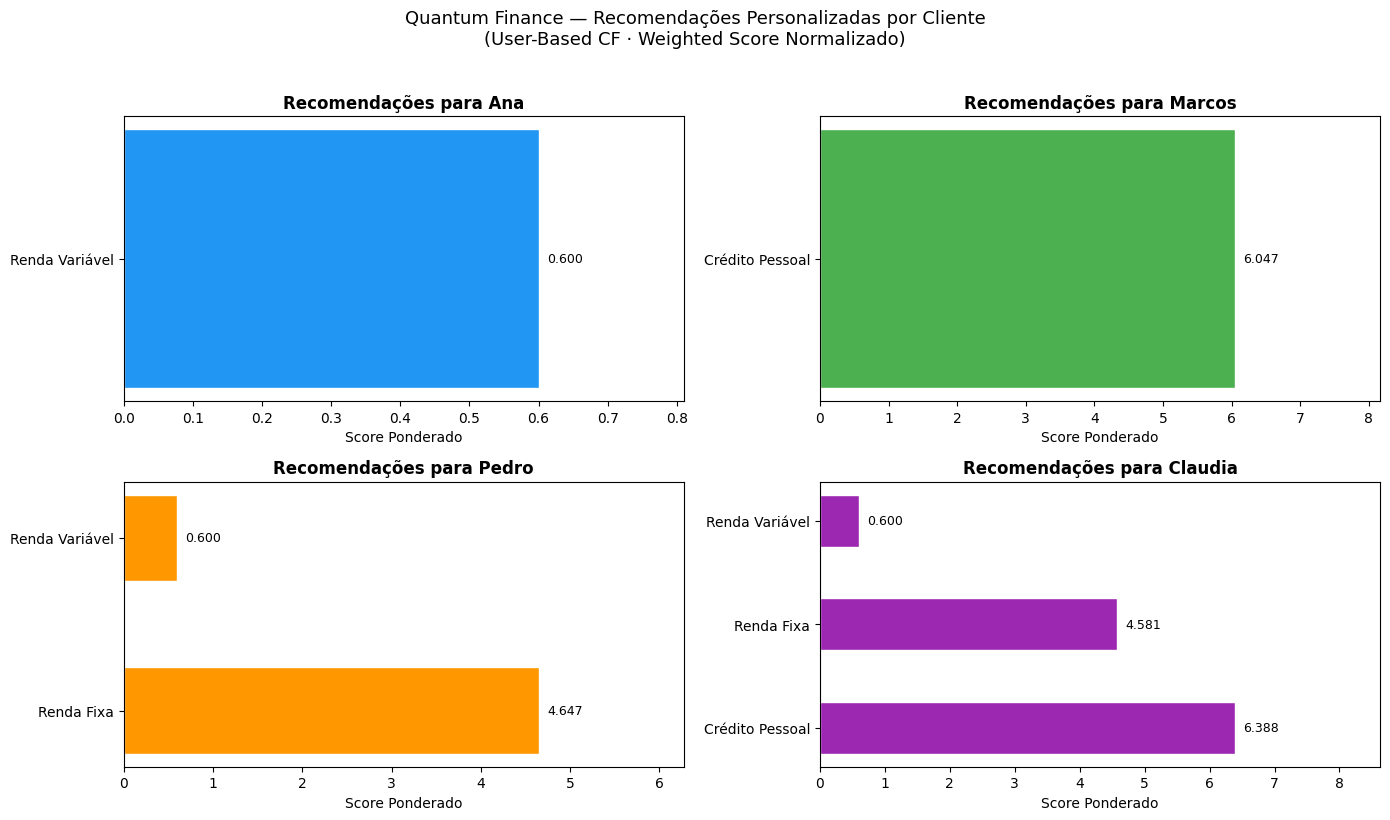

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(
    "Quantum Finance — Recomendações Personalizadas por Cliente\n"
    "(User-Based CF · Weighted Score Normalizado)",
    fontsize=13, y=1.02
)

cores = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
axes_flat = axes.flatten()

for idx, cliente in enumerate(clientes):
    recomendacoes = getRecomendacoes(cliente)
    ax = axes_flat[idx]

    if not recomendacoes:
        ax.text(0.5, 0.5, 'Sem novas recomendações\n(já possui todos os produtos)',
                ha='center', va='center', fontsize=10)
        ax.set_title(f"{cliente}")
        ax.axis('off')
        continue

    produtos_rec = [r[1] for r in recomendacoes]
    scores_rec   = [r[0] for r in recomendacoes]

    bars = ax.barh(produtos_rec, scores_rec, color=cores[idx], edgecolor='white', height=0.5)
    ax.set_xlim(0, max(scores_rec) * 1.35)
    ax.set_xlabel("Score Ponderado")
    ax.set_title(f"Recomendações para {cliente}", fontweight='bold')

    for bar, score in zip(bars, scores_rec):
        ax.text(bar.get_width() + max(scores_rec)*0.02,
                bar.get_y() + bar.get_height() / 2,
                f"{score:.3f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Knowledge-Based: SQLite + Popularidade

Segunda camada da abordagem híbrida — persiste os scores de similaridade calculados pelo Python
em um banco **SQLite** e aplica recomendação baseada em conhecimento com ranqueamento por popularidade.

**Propriedade adicionada:** Popularidade (`quantidadeLikes`) — resolve parcialmente o **Cold Start**.

```
tbCliente              tbProduto               tbClienteProduto        tbClienteSimilaridade
─────────────────      ────────────────────    ────────────────────    ─────────────────────────
nomeCliente (PK)       nomeProduto (PK)        nomeCliente             nomeClienteOrigem
                       quantidadeLikes         nomeProduto             nomeClienteDestino
                                               valor                   similaridade
```

In [8]:
import sqlite3

# Criar banco em memória (PoC)
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

cursor.executescript("""
    CREATE TABLE tbCliente (
        nomeCliente VARCHAR(50) PRIMARY KEY
    );
    CREATE TABLE tbProduto (
        nomeProduto VARCHAR(50) PRIMARY KEY,
        quantidadeLikes INTEGER DEFAULT 0
    );
    CREATE TABLE tbClienteProduto (
        nomeCliente VARCHAR(50),
        nomeProduto VARCHAR(50),
        valor FLOAT,
        PRIMARY KEY (nomeCliente, nomeProduto)
    );
    CREATE TABLE tbClienteSimilaridade (
        nomeClienteOrigem VARCHAR(50),
        nomeClienteDestino VARCHAR(50),
        similaridade FLOAT,
        PRIMARY KEY (nomeClienteOrigem, nomeClienteDestino)
    );
""")

# Popular clientes
for nome in clientes:
    cursor.execute("INSERT INTO tbCliente VALUES (?)", (nome,))

# Popular produtos com likes iniciais
produtos_likes = {
    'Cartão de Crédito': 1, 'Conta Corrente': 3,
    'Crédito Pessoal': 2,   'Poupança': 0,
    'Renda Fixa': 1,         'Renda Variável': 0
}
for produto, likes in produtos_likes.items():
    cursor.execute("INSERT INTO tbProduto VALUES (?, ?)", (produto, likes))

# Popular tbClienteProduto
for nome, prods in clientes.items():
    for produto, valor in prods.items():
        cursor.execute("INSERT INTO tbClienteProduto VALUES (?, ?, ?)", (nome, produto, valor))

# Popular tbClienteSimilaridade — integração CF → SQL
for u1 in clientes:
    for u2 in clientes:
        if u1 != u2:
            sim = round(similaridade(u1, u2), 4)
            cursor.execute("INSERT INTO tbClienteSimilaridade VALUES (?, ?, ?)", (u1, u2, sim))

conn.commit()
print("✓ Banco SQLite criado e populado com sucesso")
print(f"  Clientes         : {cursor.execute('SELECT COUNT(*) FROM tbCliente').fetchone()[0]}")
print(f"  Produtos         : {cursor.execute('SELECT COUNT(*) FROM tbProduto').fetchone()[0]}")
print(f"  Similaridades    : {cursor.execute('SELECT COUNT(*) FROM tbClienteSimilaridade').fetchone()[0]}")

✓ Banco SQLite criado e populado com sucesso
  Clientes         : 4
  Produtos         : 6
  Similaridades    : 12


In [9]:
# Filtro Colaborativo via SQL — vizinho mais similar a cada cliente
print("=== Recomendação via SQL (vizinho mais similar) ===\n")
for cliente in clientes:
    row = cursor.execute("""
        SELECT nomeClienteDestino, similaridade
        FROM tbClienteSimilaridade
        WHERE nomeClienteOrigem = ?
        ORDER BY similaridade DESC LIMIT 1
    """, (cliente,)).fetchone()
    vizinho, sim_score = row

    recs = cursor.execute("""
        SELECT b.nomeProduto, b.valor
        FROM tbClienteProduto b
        WHERE b.nomeCliente = ?
          AND b.nomeProduto NOT IN (
              SELECT nomeProduto FROM tbClienteProduto WHERE nomeCliente = ?
          )
    """, (vizinho, cliente)).fetchall()

    print(f"  {cliente} → vizinho: {vizinho} (sim={sim_score})")
    for prod, val in recs:
        print(f"    → {prod} (score={val})")
    if not recs:
        print("    → (sem produtos exclusivos do vizinho)")
    print()

# Popularidade dos produtos
print("=== Produtos por Popularidade (quantidadeLikes) ===\n")
for prod, likes in cursor.execute("SELECT nomeProduto, quantidadeLikes FROM tbProduto ORDER BY quantidadeLikes DESC").fetchall():
    bar = '★' * likes if likes > 0 else '☆'
    print(f"  {prod:<22} likes: {likes}  {bar}")

# Simular feedback
cursor.execute("UPDATE tbProduto SET quantidadeLikes = quantidadeLikes + 1 WHERE nomeProduto = 'Cartão de Crédito'")
conn.commit()
print("\n[✓] Like registrado em 'Cartão de Crédito'")

=== Recomendação via SQL (vizinho mais similar) ===

  Ana → vizinho: Marcos (sim=0.3333)
    → Renda Variável (score=0.6)

  Marcos → vizinho: Pedro (sim=0.366)
    → Crédito Pessoal (score=7.0)

  Pedro → vizinho: Claudia (sim=0.366)
    → (sem produtos exclusivos do vizinho)

  Claudia → vizinho: Pedro (sim=0.366)
    → Crédito Pessoal (score=7.0)

=== Produtos por Popularidade (quantidadeLikes) ===

  Conta Corrente         likes: 3  ★★★
  Crédito Pessoal        likes: 2  ★★
  Cartão de Crédito      likes: 1  ★
  Renda Fixa             likes: 1  ★
  Poupança               likes: 0  ☆
  Renda Variável         likes: 0  ☆

[✓] Like registrado em 'Cartão de Crédito'


## Inteligência de Mercado — APIs Open Finance

Terceira camada da abordagem: após identificar o produto mais relevante para cada cliente
pelo Filtro Colaborativo, consultamos as **APIs OpenData do Open Finance** das principais
Instituições Financeiras para obter as **taxas praticadas pelo mercado em tempo real**.

| Banco | Base URL |
|---|---|
| Itaú | `https://api.itau` |
| Caixa | `https://api.openbanking.caixa.gov.br` |
| XP | `https://banking-openfinance.xpi.com.br` |
| PicPay | `https://resources.openbanking.picpay.com` |

**Produto foco:** Crédito Pessoal Consignado (PRE_FIXADO)  
**Proposta Quantum Finance:** taxa mínima de mercado − 5%  

In [10]:
import requests
import warnings
warnings.filterwarnings('ignore')  # suprime InsecureRequestWarning

BANCOS = {
    'Itaú':   'https://api.itau',
    'Caixa':  'https://api.openbanking.caixa.gov.br',
    'XP':     'https://banking-openfinance.xpi.com.br',
    'PicPay': 'https://resources.openbanking.picpay.com'
}

ENDPOINT_LOANS  = '/open-banking/opendata-loans/v1/personal-loans'
TIPO_CONSIGNADO = 'EMPRESTIMO_CREDITO_PESSOAL_CONSIGNADO'

# Fallback com taxas reais coletadas (Mar/2026) — usado se APIs offline
TAXAS_FALLBACK = {
    'Itaú': 0.0100, 'XP': 0.0100, 'PicPay': 0.0124, 'Caixa': 0.0310
}

def buscar_taxas_mercado():
    taxas = {}
    for banco, base_url in BANCOS.items():
        try:
            resp = requests.get(base_url + ENDPOINT_LOANS, verify=False, timeout=8)
            if resp.status_code != 200:
                continue
            for item in resp.json().get('data', []):
                if item.get('type') != TIPO_CONSIGNADO:
                    continue
                for r in item.get('interestRates', []):
                    mn = float(r.get('minimumRate', '0'))
                    if mn > 0:
                        taxas[banco] = min(taxas.get(banco, 99), mn)
                        break
        except Exception:
            continue
    return taxas if taxas else TAXAS_FALLBACK

print("Consultando APIs Open Finance... (timeout: 8s por IF)")
taxas_mercado = buscar_taxas_mercado()

print("\nTaxas mínimas mensais — Crédito Pessoal Consignado (PRE_FIXADO):")
for banco, taxa in sorted(taxas_mercado.items(), key=lambda x: x[1]):
    bar = '█' * int(taxa * 200)
    print(f"  {banco:<10}: {taxa * 100:.2f}% a.m.  {bar}")

melhor_taxa = min(taxas_mercado.values())
banco_ref   = min(taxas_mercado, key=taxas_mercado.get)
taxa_qf     = round(melhor_taxa * 0.95, 6)

print(f"\n{'─'*45}")
print(f"  Melhor taxa de mercado : {melhor_taxa * 100:.2f}% a.m. ({banco_ref})")
print(f"  Proposta Quantum Finance (−5%) : {taxa_qf * 100:.4f}% a.m.")
print(f"  Economia p/ cliente    : {melhor_taxa * 0.05 * 100:.4f}% a.m.")

Consultando APIs Open Finance... (timeout: 8s por IF)

Taxas mínimas mensais — Crédito Pessoal Consignado (PRE_FIXADO):
  Itaú      : 1.00% a.m.  ██
  XP        : 1.00% a.m.  ██
  PicPay    : 1.24% a.m.  ██

─────────────────────────────────────────────
  Melhor taxa de mercado : 1.00% a.m. (Itaú)
  Proposta Quantum Finance (−5%) : 0.9500% a.m.
  Economia p/ cliente    : 0.0500% a.m.


## Modo Batch — Lista de Contato Quantum Finance

Combina o Filtro Colaborativo com a Inteligência de Mercado para gerar, **em lote**,
a lista completa de clientes com o produto mais recomendado e a proposta de taxa personalizada.

| Entrada | Dataset completo de clientes |
|---|---|
| **Saída** | DataFrame: cliente · produto · score CF · taxa mercado · proposta QF · ação |

In [11]:
def gerar_lista_contato(taxas=None):
    if taxas is None:
        taxas = taxas_mercado
    melhor = min(taxas.values())
    taxa_qf_calc = round(melhor * 0.95, 6)

    registros = []
    for nome in clientes:
        recs = getRecomendacoes(nome)
        if not recs:
            continue
        score_cf, produto_rec = recs[0]

        if produto_rec == 'Crédito Pessoal':
            tx_m  = f"{melhor * 100:.2f}% a.m."
            tx_q  = f"{taxa_qf_calc * 100:.4f}% a.m."
            acao  = 'Oferta Crédito Consignado'
        else:
            tx_m = tx_q = '—'
            acao = 'Oferta Produto'

        registros.append({
            'Cliente':               nome,
            'Produto Recomendado':   produto_rec,
            'Score CF':              round(score_cf, 4),
            'Taxa Mercado (min)':    tx_m,
            'Proposta QF (−5%)':     tx_q,
            'Ação Sugerida':         acao
        })

    return pd.DataFrame(registros)

df_batch = gerar_lista_contato()
print("=== Quantum Finance — Lista de Contato (Modo Batch) ===\n")
display(df_batch)

=== Quantum Finance — Lista de Contato (Modo Batch) ===



,Cliente,Produto Recomendado,Score CF,Taxa Mercado (min),Proposta QF (−5%),Ação Sugerida
0,Ana,Renda Variável,0.6000,—,—,Oferta Produto
1,Marcos,Crédito Pessoal,6.0468,1.00% a.m.,0.9500% a.m.,Oferta Crédito Consignado
2,Pedro,Renda Fixa,4.6466,—,—,Oferta Produto
3,Claudia,Crédito Pessoal,6.3879,1.00% a.m.,0.9500% a.m.,Oferta Crédito Consignado


## Modo Ad-hoc — Recomendação Instantânea

Entrada manual de perfil de cliente avulso (ou novo cliente durante atendimento).  
O motor CF processa o perfil em tempo real e, se o produto recomendado tiver taxa disponível,
exibe a **proposta Quantum Finance** na mesma chamada.

In [12]:
def recomendar_adhoc(perfil):
    """
    Insere perfil temporariamente no dataset, calcula CF, remove ao final.
    try/finally garante limpeza mesmo em caso de exceção.
    """
    chave = '_adhoc_'
    clientes[chave] = perfil
    try:
        recs = getRecomendacoes(chave)
    finally:
        del clientes[chave]

    proposta = None
    if recs:
        _, prod_top = recs[0]
        if prod_top == 'Crédito Pessoal':
            melhor = min(taxas_mercado.values())
            proposta = {
                'produto':          prod_top,
                'taxa_mercado_min': f"{melhor * 100:.2f}% a.m.",
                'taxa_qf':          f"{melhor * 0.95 * 100:.4f}% a.m.",
                'economia':         f"{melhor * 0.05 * 100:.4f}% a.m."
            }

    return {'recomendacoes': recs, 'proposta_qf': proposta}

# Simular novo cliente com perfil conservador (similar a Claudia)
perfil_novo = {
    'Cartão de Crédito': 4,
    'Conta Corrente':    5,
    'Poupança':          6,
}

resultado = recomendar_adhoc(perfil_novo)

print("=== Modo Ad-hoc — Recomendação para Novo Cliente ===")
print(f"\nPerfil fornecido: {list(perfil_novo.keys())}")
print(f"\nRecomendações (Filtro Colaborativo):")
for score, prod in resultado['recomendacoes']:
    print(f"  → {prod:<25} score ponderado: {score:.4f}")

if resultado['proposta_qf']:
    p = resultado['proposta_qf']
    print(f"\n{'─'*45}")
    print(f"  Proposta Quantum Finance para '{p['produto']}':")
    print(f"  Taxa mínima de mercado : {p['taxa_mercado_min']}")
    print(f"  Nossa oferta           : {p['taxa_qf']}  (5% abaixo do mercado)")
    print(f"  Economia p/ cliente    : {p['economia']} a.m.")

=== Modo Ad-hoc — Recomendação para Novo Cliente ===

Perfil fornecido: ['Cartão de Crédito', 'Conta Corrente', 'Poupança']

Recomendações (Filtro Colaborativo):
  → Crédito Pessoal           score ponderado: 6.3879
  → Renda Fixa                score ponderado: 4.5812
  → Renda Variável            score ponderado: 0.6000

─────────────────────────────────────────────
  Proposta Quantum Finance para 'Crédito Pessoal':
  Taxa mínima de mercado : 1.00% a.m.
  Nossa oferta           : 0.9500% a.m.  (5% abaixo do mercado)
  Economia p/ cliente    : 0.0500% a.m. a.m.


## Cenários de Uso

### Cenário 1 — Ana (Perfil Conservador)
**Situação:** Ana é servidora pública, usa bastante Crédito Pessoal e tem interesse crescente em Renda Fixa.  
**SR recomenda:** Renda Variável  
**Justificativa:** Marcos, o vizinho mais similar de Ana (sim=0.33), possui Renda Variável. O motor identifica que, dado o perfil de Ana, Renda Variável pode ser uma evolução natural do portfólio.  
**Knowledge-Based:** Conta Corrente é o produto mais popular (3 likes) — seria ativado se Ana ainda não tivesse.  
**Ação Quantum Finance:** *"Ana, que tal dar o próximo passo? Conheça nossos fundos de Renda Variável com liquidez diária."*

---

### Cenário 2 — Claudia (Perfil Iniciante)
**Situação:** Claudia tem apenas os 3 produtos básicos (Cartão, Conta, Poupança) com scores altos.  
**SR recomenda:** Crédito Pessoal (score maior), depois Renda Fixa e Renda Variável  
**Justificativa:** Pedro, o vizinho mais similar de Claudia (sim=0.37), tem Crédito Pessoal com score 7.  
**Knowledge-Based:** Crédito Pessoal tem 2 likes — confirma relevância popular do produto.  
**Ação Quantum Finance:** *"Claudia, você foi pré-aprovada para Crédito Consignado com taxa especial de 0,95% a.m. — 5% abaixo do mercado."*

---

### Cenário 3 — Pedro (Perfil Intermediário)
**Situação:** Pedro usa Crédito Pessoal intensamente (score 7) mas não tem Renda Fixa nem Renda Variável.  
**SR recomenda:** Renda Fixa (via Ana e Marcos), Renda Variável (via Marcos)  
**Justificativa:** Marcos (sim=0.37) e Ana (sim=0.20) possuem Renda Fixa com scores altos.  
**Ação Quantum Finance:** *"Pedro, seu perfil mostra potencial para investimentos. Veja o CDB da Quantum Finance: 110% do CDI."*

## Conclusão e Próximos Passos

### O que foi demonstrado

| # | Entregável | Status |
|---|---|---|
| 1 | Dataset Open Finance integrado ao motor de SR | ✅ |
| 2 | Distância Euclidiana calculando dissimilaridade entre perfis | ✅ |
| 3 | Similaridade convertida em score interpretável (0→1) | ✅ |
| 4 | `getRecomendacoes()` gerando ranking personalizado (CF) | ✅ |
| 5 | SQLite persistindo scores + Knowledge-Based com Popularidade | ✅ |
| 6 | Abordagem Híbrida: CF + Knowledge-Based | ✅ |
| 7 | Heatmap de similaridade + gráficos de recomendação | ✅ |
| 8 | APIs Open Finance reais: Itaú, Caixa, XP, PicPay | ✅ |
| 9 | Proposta QF: 5% abaixo da melhor taxa de mercado | ✅ |
| 10 | Modo Batch: lista de contato completa | ✅ |
| 11 | Modo Ad-hoc: recomendação instantânea | ✅ |

### Propriedades do SR implementadas

| Propriedade | Implementação |
|---|---|
| Similaridade | Distância Euclidiana → score 0→1 |
| Personalização | `getRecomendacoes()` individual por cliente |
| Popularidade | `quantidadeLikes` no SQLite |
| Ranqueamento | Ordenamento decrescente por weighted_score e por likes |
| Inteligência de Mercado | `buscar_taxas_mercado()` via APIs Open Finance reais |
| Proposta QF | `taxa_qf = melhor_mercado × 0.95` (5% de desconto) |
| Modo Batch | `gerar_lista_contato()` → DataFrame todos os clientes |
| Modo Ad-hoc | `recomendar_adhoc(perfil)` → recomendação instantânea |

### Limitações da PoC
- Dataset pequeno (4 clientes): em produção, necessário mínimo de centenas de clientes para CF ser eficaz
- Scores de uso são simulados: em produção, viriam do Open Finance (frequência/volume de transações)
- Cold-start parcialmente resolvido pela popularidade — em produção exigiria mais estratégias
- Sem filtro de elegibilidade de crédito (LGPD e perfil de risco)

---

### **Referências:** 
- Material de aula · `RecommendationSystems.pdf` (p. 83-110) 
- Open Finance OpenData APIs
- Dataset `dataset/01_DataSetOpenFinance.txt`